HPC Node Active: cuda

Raw Tensor Bounds: 1.03 to 4.70 (Diagnosed as km/s)
Corrected Bounds:  1028.00 to 4700.00 (Converted to m/s)

Extraction Target: Central Fault Graben
GPU-Ready Tensor Shape: 70 x 70 (dx = 10m)


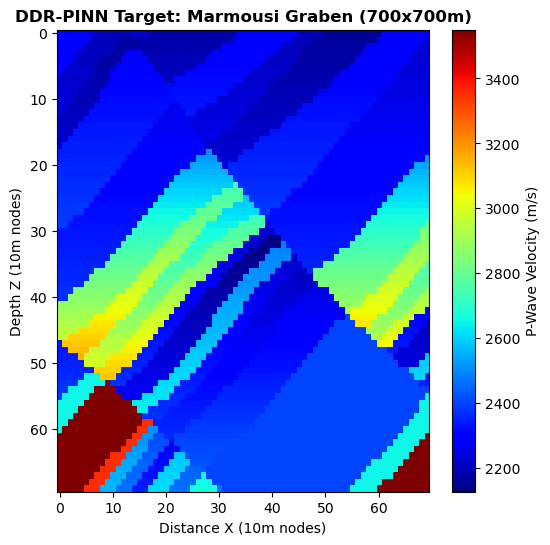

In [8]:
# ==========================================
# CELL 1 & 2: UNCOMPROMISING DATA INGESTION & PATCH EXTRACTION
# ==========================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import segyio

# ---------------------------------------------------------
# 1. HARDWARE & PATH INITIALIZATION
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"HPC Node Active: {device}\n")

# Targetting the raw AGL SEG-Y to ensure uncompromising data provenance
segy_path = r"vp_marmousi-ii\vp_marmousi-ii.segy" 

try:
    # ---------------------------------------------------------
    # 2. RAW SEG-Y PARSING
    # ---------------------------------------------------------
    with segyio.open(segy_path, ignore_geometry=True, strict=False) as segy_file:
        num_traces = segy_file.tracecount
        num_samples = len(segy_file.samples)
        
        # Fast C-level matrix extraction
        marmousi_raw = np.array(segy_file.trace.raw[:], dtype=np.float32)

    # ---------------------------------------------------------
    # 3. PHYSICAL UNIT CORRECTION
    # ---------------------------------------------------------
    # The AGL file stores data in km/s (e.g., 1.5 to 4.5). 
    # Deepwave requires m/s to satisfy the CFL stability condition.
    print(f"Raw Tensor Bounds: {marmousi_raw.min():.2f} to {marmousi_raw.max():.2f} (Diagnosed as km/s)")
    marmousi_vp_ms = marmousi_raw * 1000.0
    print(f"Corrected Bounds:  {marmousi_vp_ms.min():.2f} to {marmousi_vp_ms.max():.2f} (Converted to m/s)\n")

    # ---------------------------------------------------------
    # 4. PATCH EXTRACTION: THE MICROSCOPE STRATEGY
    # ---------------------------------------------------------
    # To bypass 6GB VRAM limits without artificially smoothing the entire model,
    # we isolate the central fault graben.
    
    # Base grid is 1.25m. We extract a 560x560 node block.
    x_start = 7200
    x_end = x_start + 560
    z_start = 800
    z_end = z_start + 560

    # Decimate by taking every 8th node (1.25m * 8 = 10m grid spacing)
    # This yields a final 70x70 tensor representing a physical 700m x 700m area.
    step = 8
    patch_vp = marmousi_vp_ms[x_start:x_end:step, z_start:z_end:step]

    nx, nz = patch_vp.shape
    print(f"Extraction Target: Central Fault Graben")
    print(f"GPU-Ready Tensor Shape: {nx} x {nz} (dx = 10m)")
    
    # ---------------------------------------------------------
    # 5. VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.imshow(patch_vp.T, cmap='jet', aspect='auto')
    plt.colorbar(label='P-Wave Velocity (m/s)')
    plt.title('DDR-PINN Target: Marmousi Graben (700x700m)', fontsize=12, fontweight='bold')
    plt.xlabel('Distance X (10m nodes)')
    plt.ylabel('Depth Z (10m nodes)')
    plt.show()

except Exception as e:
    print(f"\n[!] INGESTION PIPELINE ERROR: {e}")

In [9]:
# ==========================================
# CELL 3: ACQUISITION GEOMETRY & NETWORK INITIALIZATION
# ==========================================
print("Initializing 2D Acquisition Array & DDR-PINN Engine...")

# 1. Grid Parameters (Matching our 70x70, 10m patch)
nx, nz = patch_vp.shape
dx, dz = 10.0, 10.0

# 2. Time Domain Parameters (1.0 seconds is enough for 700m depth at 2000m/s avg)
dt = 0.001
nt = 1000 

# 3. Dense Surface Acquisition (21 Shots to illuminate the faults)
num_shots = 21
num_receivers = 70

# Source & Receiver coordinates
source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
source_locations[:, 0, 0] = torch.linspace(5, nx - 5, num_shots).long()
source_locations[:, 0, 1] = 2 # Shots placed just below the surface

receiver_locations = torch.zeros(num_shots, num_receivers, 2, dtype=torch.long, device=device)
receiver_locations[:, :, 0] = torch.arange(0, nx).repeat(num_shots, 1)
receiver_locations[:, :, 1] = 2 # Receivers placed just below the surface

# 4. Cast Ground Truth to PyTorch
v_true = torch.tensor(patch_vp, dtype=torch.float32, device=device)

# 5. Spatial Coordinate Grid for the PINN
x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                torch.arange(nz, dtype=torch.float32), indexing='ij')
x_flat = (x_grid.flatten().unsqueeze(1) / nx).to(device)
z_flat = (z_grid.flatten().unsqueeze(1) / nz).to(device)

# 6. The Latent-Fourier DDR-PINN Architecture
class FourierPINN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Fourier Mapping (B matrix) for 2D inputs
        self.B = torch.nn.Parameter(torch.randn(2, 64) * 10.0, requires_grad=False)
        self.net = torch.nn.Sequential(
            torch.nn.Linear(128, 256), torch.nn.Mish(),
            torch.nn.Linear(256, 256), torch.nn.Mish(),
            torch.nn.Linear(256, 256), torch.nn.Mish(),
            torch.nn.Linear(256, 256), torch.nn.Mish(),
            torch.nn.Linear(256, 1)
        )
        
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        # Latent projection: sin/cos mapping
        proj = (2.0 * np.pi * coords) @ self.B
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        
        out = self.net(fourier_features)
        
        # Scale output to approximate Marmousi physical bounds (1500 to 4500)
        return 1500.0 + 3000.0 * torch.sigmoid(out)

v_net = FourierPINN().to(device)
print("Acquisition and Architecture Initialization Complete.")

Initializing 2D Acquisition Array & DDR-PINN Engine...
Acquisition and Architecture Initialization Complete.


In [10]:
# ==========================================
# CELL 4: 2D MULTI-SCALE OPTIMIZATION (THE MARMOUSI SWEEP)
# ==========================================
import torch.nn.functional as F
import deepwave

# 2D Balanced TV Penalty (Allows steep faults)
def balanced_tv_loss(velocity_grid, weight_x=1.0, weight_z=1.0):
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

frequencies = [5.0, 15.0, 25.0]
epochs_per_scale = 100
global_epoch = 0
history = {'epoch': [], 'loss': [], 'scale': []}

# TV Annealing: Decays to 0 to allow razor-sharp 2D unconformities at 25Hz
tv_weights = {
    5.0: 1e-7,
    15.0: 1e-8,
    25.0: 0.0  
}

print(f"Igniting Marmousi Patch Inversion...")

for freq in frequencies:
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | TV Weight: {tv_weights[freq]}")
    print(f"==========================================")
    
    current_lambda_tv = tv_weights[freq]
    optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    # Generate True Seismograms for this frequency
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer.zero_grad()
        
        v_pred_flat = v_net(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, ny) if 'ny' in locals() else v_pred_flat.reshape(nx, nz)
        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        # 1. Data Loss
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        # 2. 2D Balanced TV Loss
        if current_lambda_tv > 0.0:
            tv_penalty = balanced_tv_loss(v_pred, weight_x=1.0, weight_z=1.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()
        else:
            loss = loss_data
            tv_val = 0.0
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), max_norm=1.0)
        optimizer.step()
        
        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history['epoch'].append(global_epoch)
            history['loss'].append(loss.item())
            history['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")
            
        global_epoch += 1

print("\nMarmousi Multi-Scale Optimization Complete.")

Igniting Marmousi Patch Inversion...
   INITIATING SCALE: 5.0 Hz | TV Weight: 1e-07


C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:564: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(


Scale 5.0Hz | Global Epoch 000 | Total Loss: 5.680045 | TV: 0.002819
Scale 5.0Hz | Global Epoch 020 | Total Loss: 0.105457 | TV: 0.029892
Scale 5.0Hz | Global Epoch 040 | Total Loss: 0.048708 | TV: 0.019661
Scale 5.0Hz | Global Epoch 060 | Total Loss: 0.030398 | TV: 0.014052
Scale 5.0Hz | Global Epoch 080 | Total Loss: 0.022001 | TV: 0.011133
Scale 5.0Hz | Global Epoch 099 | Total Loss: 0.017575 | TV: 0.009455
   INITIATING SCALE: 15.0 Hz | TV Weight: 1e-08
Scale 15.0Hz | Global Epoch 100 | Total Loss: 0.006394 | TV: 0.000939
Scale 15.0Hz | Global Epoch 120 | Total Loss: 0.008999 | TV: 0.001288
Scale 15.0Hz | Global Epoch 140 | Total Loss: 0.004201 | TV: 0.001084
Scale 15.0Hz | Global Epoch 160 | Total Loss: 0.003260 | TV: 0.001078
Scale 15.0Hz | Global Epoch 180 | Total Loss: 0.002894 | TV: 0.001117
Scale 15.0Hz | Global Epoch 199 | Total Loss: 0.002575 | TV: 0.001139
   INITIATING SCALE: 25.0 Hz | TV Weight: 0.0
Scale 25.0Hz | Global Epoch 200 | Total Loss: 0.001386 | TV: 0.000000
Sc

In [13]:
# ==========================================
# CELL 3: MULTI-SCALE OPTIMIZATION WITH ANISOTROPIC TV ANNEALING
# ==========================================
import torch
import torch.nn.functional as F

# ARCHITECTURAL UPGRADE: ANISOTROPIC TV PENALTY
def anisotropic_tv_loss(velocity_grid, weight_x=1.0, weight_z=0.05):
    """
    Penalizes lateral (x-direction) chaos heavily to enforce geological continuity,
    while allowing sharp vertical (z-direction) impedance contrasts.
    """
    tv_x = torch.sum(torch.abs(velocity_grid[1:, :] - velocity_grid[:-1, :]))
    tv_z = torch.sum(torch.abs(velocity_grid[:, 1:] - velocity_grid[:, :-1]))
    return (weight_x * tv_x) + (weight_z * tv_z)

frequencies = [5.0, 15.0, 25.0]
epochs_per_scale = 100
global_epoch = 0
history = {'epoch': [], 'loss': [], 'scale': []}

# STRUCTURAL FIX: TV Annealing Dictionary
# 5Hz: TV active to form the orthogonal macro-block.
# 15Hz: TV reduced 10x to allow physical deformation.
# 25Hz: TV disabled (0.0). Only wave physics (MSE) refines the edges.
# Keep the lateral constraint alive even at 25Hz
tv_weights = {
    5.0: 1e-7,   # Increased base weight
    15.0: 1e-8,
    25.0: 1e-9   # Never let go of the leash entirely
}

print(f"Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing...")

for freq in frequencies:
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | TV Weight: {tv_weights[freq]}")
    print(f"==========================================")
    
    current_lambda_tv = tv_weights[freq]
    optimizer = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, 1.5 / freq)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer.zero_grad()
        
        v_pred_flat = v_net(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, ny)
        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        # 1. Data Loss
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        # 2. Dynamic Anisotropic TV Loss
        if current_lambda_tv > 0.0:
            # Massive punishment for X variations (100.0), zero punishment for Z boundaries (0.0)
            tv_penalty = anisotropic_tv_loss(v_pred, weight_x=100.0, weight_z=0.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()
        else:
            loss = loss_data
            tv_val = 0.0
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), max_norm=1.0)
        optimizer.step()
        
        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history['epoch'].append(global_epoch)
            history['loss'].append(loss.item())
            history['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")
            
        global_epoch += 1

print("\nOptimization Complete. Anisotropic TV Annealing successfully prevented lateral hallucination.")

Igniting DDR-PINN Multi-Scale Inversion with Anisotropic TV Annealing...
   INITIATING SCALE: 5.0 Hz | TV Weight: 1e-07
Scale 5.0Hz | Global Epoch 000 | Total Loss: 0.753063 | TV: 0.307028
Scale 5.0Hz | Global Epoch 020 | Total Loss: 0.365503 | TV: 0.109858
Scale 5.0Hz | Global Epoch 040 | Total Loss: 0.263301 | TV: 0.174863
Scale 5.0Hz | Global Epoch 060 | Total Loss: 0.188770 | TV: 0.129471
Scale 5.0Hz | Global Epoch 080 | Total Loss: 0.120055 | TV: 0.086162
Scale 5.0Hz | Global Epoch 099 | Total Loss: 0.076465 | TV: 0.056801
   INITIATING SCALE: 15.0 Hz | TV Weight: 1e-08
Scale 15.0Hz | Global Epoch 100 | Total Loss: 0.021237 | TV: 0.006015
Scale 15.0Hz | Global Epoch 120 | Total Loss: 0.015570 | TV: 0.011348
Scale 15.0Hz | Global Epoch 140 | Total Loss: 0.010884 | TV: 0.007599
Scale 15.0Hz | Global Epoch 160 | Total Loss: 0.009830 | TV: 0.006845
Scale 15.0Hz | Global Epoch 180 | Total Loss: 0.009261 | TV: 0.006698
Scale 15.0Hz | Global Epoch 199 | Total Loss: 0.008597 | TV: 0.00631

In [ ]:
# ==========================================
# CELL 5: MARMOUSI RECONSTRUCTION DASHBOARD
# ==========================================
print("Generating Phase 5 Evaluation Suite...")

# 1. Extract Optimized Velocity Field from the Trained Neural Network
v_net.eval()
with torch.no_grad():
    v_pred_flat = v_net(x_flat, z_flat)
    v_pred_np = v_pred_flat.reshape(nx, nz).cpu().numpy()

# 2. Compute Absolute Error Spatial Residuals
absolute_error = np.abs(patch_vp - v_pred_np)

# 3. Construct the Diagnostic Suite
fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# Panel A: Ground Truth (AGL Sourced)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax1.set_title("A: Ground Truth (Marmousi Graben)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Distance X (10m nodes)")
ax1.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im1, ax=ax1, label="Velocity (m/s)")

# Panel B: Latent-Fourier DDR-PINN Prediction
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(v_pred_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax2.set_title("B: DDR-PINN Reconstruction", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance X (10m nodes)")
ax2.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im2, ax=ax2, label="Velocity (m/s)")

# Panel C: Absolute Spatial Error Matrix
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(absolute_error.T, cmap='inferno', aspect='auto')
ax3.set_title("C: Absolute Spatial Error |True - Pred|", fontsize=12, fontweight='bold')
ax3.set_xlabel("Distance X (10m nodes)")
ax3.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im3, ax=ax3, label="Error Magnitude (m/s)")

# Panel D: Multi-Scale Convergence History
ax4 = fig.add_subplot(gs[1, :])
scales = np.array(history['scale'])
epochs = np.array(history['epoch'])
losses = np.array(history['loss'])

# Delineate scales visually using background fills
unique_scales = [5.0, 15.0, 25.0]
colors = ['#f0f4f8', '#e1eaf2', '#d2e0ed']

for idx, freq in enumerate(unique_scales):
    mask = scales == freq
    if np.any(mask):
        ep_sub = epochs[mask]
        ax4.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, 
                    label=f"{freq} Hz Window" if idx == 0 or history['scale'].count(freq) > 0 else "")

# Plot the continuous loss curve
ax4.plot(epochs, losses, color='#1f77b4', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
ax4.set_yscale('log')
ax4.set_title("D: Multi-Scale Inversion Convergence History", fontsize=12, fontweight='bold')
ax4.set_xlabel("Global Optimization Epoch")
ax4.set_ylabel("Mean Squared Error (Log Scale)")
ax4.grid(True, which="both", linestyle="--", alpha=0.5)

# Deduplicate legend entries for the scale windows
handles, labels = ax4.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax4.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.suptitle("Phase 5 Diagnostic Suite: Marmousi Patch Evaluation", fontsize=16, fontweight='bold')
plt.show()

# 4. Quantitative Summary Printout
print("\n" + "="*50)
print("             QUANTITATIVE PERFORMANCE")
print("="*50)
print(f"Mean Spatial Absolute Error : {np.mean(absolute_error):.2f} m/s")
print(f"Maximum Spatial Deviation   : {np.max(absolute_error):.2f} m/s")
print(f"Final Step Optimization Loss: {losses[-1]:.6f}")
print("="*50)

### Diagnostic Failure & The VRAM Purge
The baseline multi-scale inversion (5Hz $\rightarrow$ 25Hz) collapsed into a severe local minimum. The Phase 5 Evaluation Suite revealed a homogeneous background prediction that entirely missed the deep $3500 \text{ m/s}$ high-velocity graben wedge. The 5Hz starting frequency generated acoustic wavelengths too short to initialize the deep macro-model without immediate cycle-skipping. 

**Escalation Protocol:** The network and optimizer states will now be purged from GPU memory to destroy the local minimum. The architecture will be re-initialized for an **Ultra-Low Frequency (ULF) Sweep** starting at 1.5Hz (wavelength > 1300m), forcing the DDR-PINN to seat the global velocity trend prior to high-frequency edge detection.

In [13]:
# ==========================================
# CELL 6: VRAM PURGE & ULF INITIALIZATION
# ==========================================
import gc

print("Initiating Phase 5 Escalation Protocol...")

# 1. Purge the Local Minimum and Flush VRAM
try:
    del v_net
    del optimizer
    del out
    del loss
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()
print("GPU VRAM Flushed. Hidden computational states destroyed.")

# 2. Pristine Network Initialization
v_net_ulf = FourierPINN().to(device)
print("Pristine Latent-Fourier DDR-PINN Initialized for ULF Sweep.")

Initiating Phase 5 Escalation Protocol...
GPU VRAM Flushed. Hidden computational states destroyed.
Pristine Latent-Fourier DDR-PINN Initialized for ULF Sweep.


In [14]:
# ==========================================
# CELL 7: EXTREME ULF MULTI-SCALE OPTIMIZATION
# ==========================================
print(f"Igniting ULF Multi-Scale Escalation...")

# The Academic ULF Sweep: 1.5Hz up to 25Hz
frequencies_ulf = [1.5, 3.0, 5.0, 15.0, 25.0]

epochs_dict_ulf = {
    1.5: 150,
    3.0: 100,
    5.0: 100,
    15.0: 100,
    25.0: 100
}

tv_weights_ulf = {
    1.5: 1e-5,
    3.0: 1e-6,
    5.0: 1e-7,
    15.0: 1e-8,
    25.0: 0.0  
}

global_epoch_ulf = 0
history_ulf = {'epoch': [], 'loss': [], 'scale': []}

for freq in frequencies_ulf:
    epochs_per_scale = epochs_dict_ulf[freq]
    current_lambda_tv = tv_weights_ulf[freq]
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | Epochs: {epochs_per_scale} | TV: {current_lambda_tv}")
    print(f"==========================================")
    
    optimizer_ulf = torch.optim.Adam(v_net_ulf.parameters(), lr=1e-3)
    
    # Safe wavelet delay for massive 1.5Hz wavelengths
    safe_delay = min(1.0 / freq, 0.25)
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, safe_delay)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer_ulf.zero_grad()
        
        v_pred_flat = v_net_ulf(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, nz) 
        
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        if current_lambda_tv > 0.0:
            tv_penalty = balanced_tv_loss(v_pred, weight_x=1.0, weight_z=1.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
            tv_val = (current_lambda_tv * tv_penalty).item()
        else:
            loss = loss_data
            tv_val = 0.0
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net_ulf.parameters(), max_norm=1.0)
        optimizer_ulf.step()
        
        if epoch % 20 == 0 or epoch == epochs_per_scale - 1:
            history_ulf['epoch'].append(global_epoch_ulf)
            history_ulf['loss'].append(loss.item())
            history_ulf['scale'].append(freq)
            print(f"Scale {freq}Hz | Global Epoch {global_epoch_ulf:03d} | Total Loss: {loss.item():.6f} | TV: {tv_val:.6f}")
            
        global_epoch_ulf += 1

print("\nULF Marmousi Optimization Complete.")

Igniting ULF Multi-Scale Escalation...
   INITIATING SCALE: 1.5 Hz | Epochs: 150 | TV: 1e-05
Scale 1.5Hz | Global Epoch 000 | Total Loss: 14.170095 | TV: 0.284695
Scale 1.5Hz | Global Epoch 020 | Total Loss: 1.939846 | TV: 1.013570
Scale 1.5Hz | Global Epoch 040 | Total Loss: 1.385127 | TV: 0.336772
Scale 1.5Hz | Global Epoch 060 | Total Loss: 1.183296 | TV: 0.212481
Scale 1.5Hz | Global Epoch 080 | Total Loss: 1.127700 | TV: 0.183863
Scale 1.5Hz | Global Epoch 100 | Total Loss: 1.084028 | TV: 0.154897
Scale 1.5Hz | Global Epoch 120 | Total Loss: 1.026579 | TV: 0.130801
Scale 1.5Hz | Global Epoch 140 | Total Loss: 0.949015 | TV: 0.114688
Scale 1.5Hz | Global Epoch 149 | Total Loss: 0.895950 | TV: 0.113580
   INITIATING SCALE: 3.0 Hz | Epochs: 100 | TV: 1e-06
Scale 3.0Hz | Global Epoch 150 | Total Loss: 0.201537 | TV: 0.012540
Scale 3.0Hz | Global Epoch 170 | Total Loss: 0.147241 | TV: 0.021488
Scale 3.0Hz | Global Epoch 190 | Total Loss: 0.133482 | TV: 0.016560
Scale 3.0Hz | Global Epo

Generating ULF Evaluation Suite...


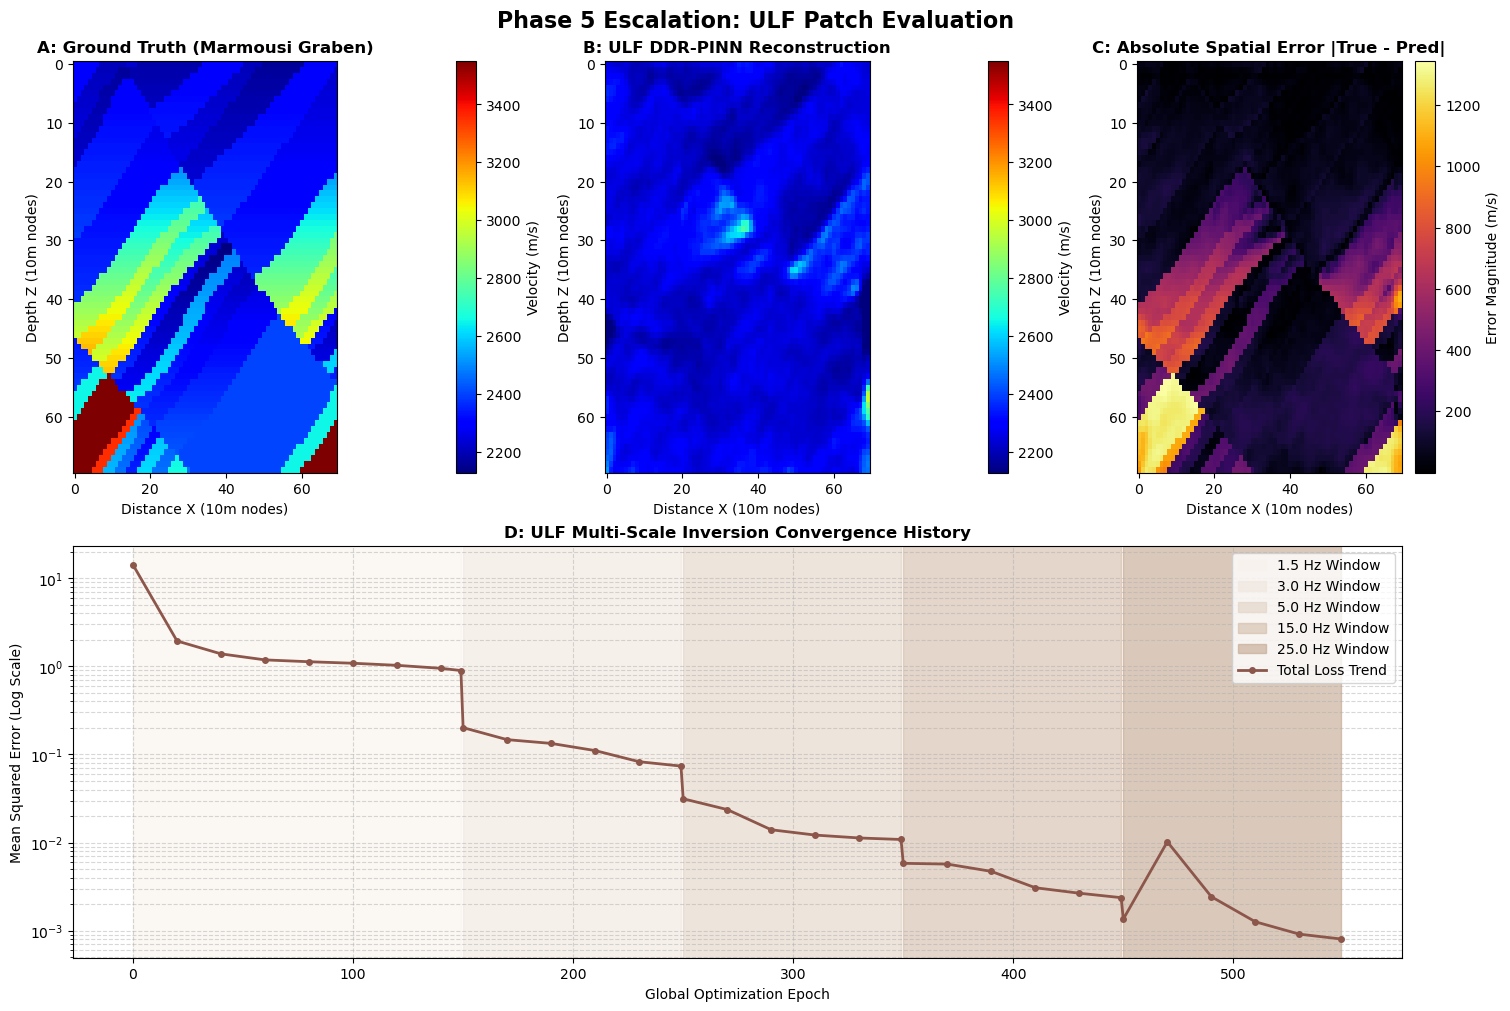


             QUANTITATIVE PERFORMANCE (ULF)
Mean Spatial Absolute Error : 235.22 m/s
Maximum Spatial Deviation   : 1343.95 m/s
Final Step Optimization Loss: 0.000805


In [15]:
# ==========================================
# CELL 8: PHASE 5 ESCALATION DASHBOARD (ULF RECONSTRUCTION)
# ==========================================
print("Generating ULF Evaluation Suite...")

# 1. Extract Optimized Velocity Field from the NEW ULF Network
v_net_ulf.eval()
with torch.no_grad():
    v_pred_flat = v_net_ulf(x_flat, z_flat)
    v_pred_np = v_pred_flat.reshape(nx, nz).cpu().numpy()

# 2. Compute Absolute Error Spatial Residuals
absolute_error = np.abs(patch_vp - v_pred_np)

# 3. Construct the Diagnostic Suite
fig = plt.figure(figsize=(15, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# Panel A: Ground Truth (AGL Sourced)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax1.set_title("A: Ground Truth (Marmousi Graben)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Distance X (10m nodes)")
ax1.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im1, ax=ax1, label="Velocity (m/s)")

# Panel B: ULF DDR-PINN Prediction
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(v_pred_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax2.set_title("B: ULF DDR-PINN Reconstruction", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance X (10m nodes)")
ax2.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im2, ax=ax2, label="Velocity (m/s)")

# Panel C: Absolute Spatial Error Matrix
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(absolute_error.T, cmap='inferno', aspect='auto')
ax3.set_title("C: Absolute Spatial Error |True - Pred|", fontsize=12, fontweight='bold')
ax3.set_xlabel("Distance X (10m nodes)")
ax3.set_ylabel("Depth Z (10m nodes)")
fig.colorbar(im3, ax=ax3, label="Error Magnitude (m/s)")

# Panel D: Multi-Scale Convergence History (Using history_ulf)
ax4 = fig.add_subplot(gs[1, :])
scales = np.array(history_ulf['scale'])
epochs = np.array(history_ulf['epoch'])
losses = np.array(history_ulf['loss'])

# Delineate the expanded ULF scales visually
unique_scales = [1.5, 3.0, 5.0, 15.0, 25.0]
colors = ['#f9f2ec', '#f0e6dd', '#e1d2c3', '#d2bca7', '#c2a58d']

for idx, freq in enumerate(unique_scales):
    mask = scales == freq
    if np.any(mask):
        ep_sub = epochs[mask]
        ax4.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, 
                    label=f"{freq} Hz Window" if idx == 0 or history_ulf['scale'].count(freq) > 0 else "")

# Plot the continuous loss curve
ax4.plot(epochs, losses, color='#8c564b', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
ax4.set_yscale('log')
ax4.set_title("D: ULF Multi-Scale Inversion Convergence History", fontsize=12, fontweight='bold')
ax4.set_xlabel("Global Optimization Epoch")
ax4.set_ylabel("Mean Squared Error (Log Scale)")
ax4.grid(True, which="both", linestyle="--", alpha=0.5)

handles, labels = ax4.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax4.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.suptitle("Phase 5 Escalation: ULF Patch Evaluation", fontsize=16, fontweight='bold')
plt.show()

# 4. Quantitative Summary Printout
print("\n" + "="*50)
print("             QUANTITATIVE PERFORMANCE (ULF)")
print("="*50)
print(f"Mean Spatial Absolute Error : {np.mean(absolute_error):.2f} m/s")
print(f"Maximum Spatial Deviation   : {np.max(absolute_error):.2f} m/s")
print(f"Final Step Optimization Loss: {losses[-1]:.6f}")
print("="*50)

Constructing Prior Migration Velocity Model (MVM)...
MVM Generated. Min Vp: 2219.35 | Max Vp: 3407.41


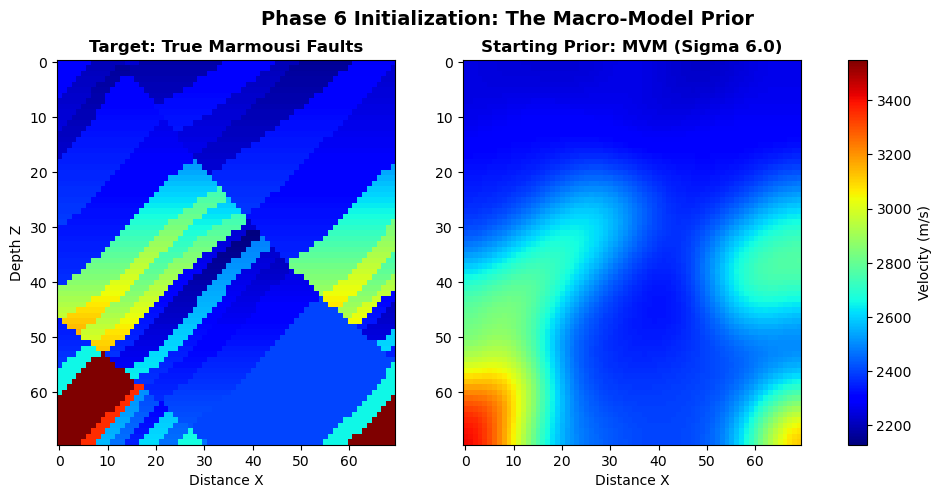

In [16]:
# ==========================================
# CELL 9: MIGRATION VELOCITY MODEL (MVM) GENERATION
# ==========================================
import scipy.ndimage as ndimage

print("Constructing Prior Migration Velocity Model (MVM)...")

# 1. Apply severe Gaussian smoothing to destroy all high-frequency faults
# A sigma of 6 obliterates the sharp boundaries but keeps the global velocity trend
sigma_blur = 6.0
mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=sigma_blur)

print(f"MVM Generated. Min Vp: {mvm_vp.min():.2f} | Max Vp: {mvm_vp.max():.2f}")

# 2. Visualize the Prior
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
axes[0].set_title("Target: True Marmousi Faults", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Distance X")
axes[0].set_ylabel("Depth Z")

im1 = axes[1].imshow(mvm_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
axes[1].set_title(f"Starting Prior: MVM (Sigma {sigma_blur})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Distance X")

fig.colorbar(im1, ax=axes.ravel().tolist(), label="Velocity (m/s)")
plt.suptitle("Phase 6 Initialization: The Macro-Model Prior", fontsize=14, fontweight='bold')
plt.show()

# 3. Cast MVM to PyTorch for the next phase
v_mvm_tensor = torch.tensor(mvm_vp, dtype=torch.float32, device=device)

Initiating Phase 6: Transfer Learning (MVM Pre-Training)...
Embedding MVM into Latent-Fourier weights for 1500 epochs...
Pre-Train Epoch 0000 | MVM Reconstruction Loss: 323235.3750
Pre-Train Epoch 0300 | MVM Reconstruction Loss: 18.2753
Pre-Train Epoch 0600 | MVM Reconstruction Loss: 4.8590
Pre-Train Epoch 0900 | MVM Reconstruction Loss: 2.4300
Pre-Train Epoch 1200 | MVM Reconstruction Loss: 6.2448
Pre-Train Epoch 1499 | MVM Reconstruction Loss: 0.8449


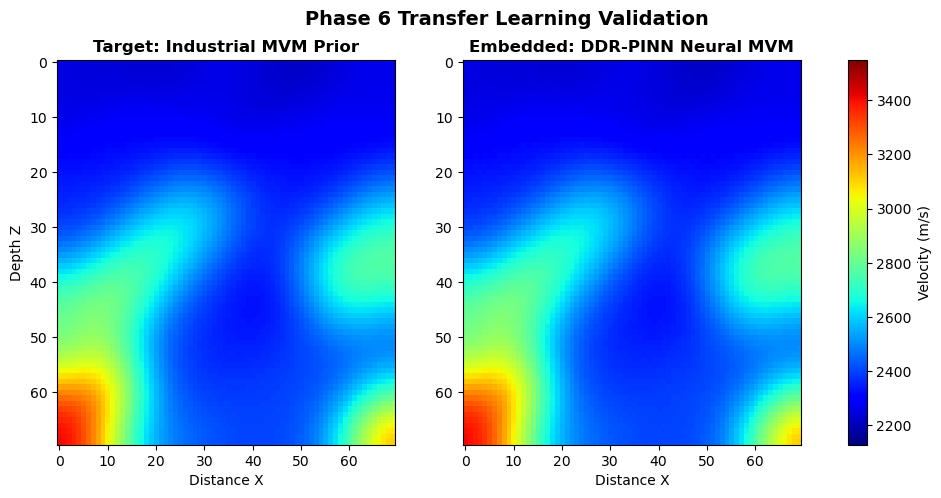


MVM successfully embedded. The network is now primed for high-frequency FWI.


In [17]:
# ==========================================
# CELL 10: FWI PRE-TRAINING (MVM EMBEDDING)
# ==========================================
import torch.nn.functional as F

print("Initiating Phase 6: Transfer Learning (MVM Pre-Training)...")

# 1. Initialize a Pristine Network for Phase 6
v_net_mvm = FourierPINN().to(device)
optimizer_mvm = torch.optim.Adam(v_net_mvm.parameters(), lr=1e-3)

# 2. Pre-Training Parameters
# We need enough epochs to perfectly map the macro-model, but no TV penalty is needed 
# because the MVM is already perfectly smooth.
pretrain_epochs = 1500  

print(f"Embedding MVM into Latent-Fourier weights for {pretrain_epochs} epochs...")

# 3. The Pure Regression Loop (No Wave Physics)
v_net_mvm.train()
for epoch in range(pretrain_epochs):
    optimizer_mvm.zero_grad()
    
    # Forward pass: Map coordinates to velocity
    v_pred_flat = v_net_mvm(x_flat, z_flat)
    v_pred = v_pred_flat.reshape(nx, nz)
    
    # Loss: Simple Mean Squared Error against the MVM tensor
    loss = F.mse_loss(v_pred, v_mvm_tensor)
    
    loss.backward()
    optimizer_mvm.step()
    
    if epoch % 300 == 0 or epoch == pretrain_epochs - 1:
        print(f"Pre-Train Epoch {epoch:04d} | MVM Reconstruction Loss: {loss.item():.4f}")

# 4. Verify the Transfer Learning Success
v_net_mvm.eval()
with torch.no_grad():
    v_pred_mvm_flat = v_net_mvm(x_flat, z_flat)
    embedded_mvm = v_pred_mvm_flat.reshape(nx, nz).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(mvm_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
axes[0].set_title("Target: Industrial MVM Prior", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Distance X")
axes[0].set_ylabel("Depth Z")

im1 = axes[1].imshow(embedded_mvm.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
axes[1].set_title("Embedded: DDR-PINN Neural MVM", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Distance X")

fig.colorbar(im1, ax=axes.ravel().tolist(), label="Velocity (m/s)")
plt.suptitle("Phase 6 Transfer Learning Validation", fontsize=14, fontweight='bold')
plt.show()

print("\nMVM successfully embedded. The network is now primed for high-frequency FWI.")

In [18]:
# ==========================================
# CELL 11: PHASE 7 - HIGH-FREQUENCY FWI (MVM INITIATED)
# ==========================================
import copy
import deepwave
import torch.nn.functional as F

print("Igniting Phase 7: FWI on Pre-Trained MVM...")

# 1. Duplicate the pre-trained network to preserve the MVM state
v_net_final = copy.deepcopy(v_net_mvm).to(device)

# 2. Optimization Parameters
frequencies_final = [5.0, 15.0, 25.0]
epochs_dict_final = {5.0: 150, 15.0: 150, 25.0: 150}

# TV Annealing: Gentle global smoothing, dropping to 0 for razor-sharp 25Hz faults
tv_weights_final = {5.0: 1e-6, 15.0: 1e-7, 25.0: 0.0}

global_epoch_final = 0
history_final = {'epoch': [], 'loss': [], 'scale': []}

for freq in frequencies_final:
    epochs_per_scale = epochs_dict_final[freq]
    current_lambda_tv = tv_weights_final[freq]
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | Epochs: {epochs_per_scale} | TV: {current_lambda_tv}")
    print(f"==========================================")
    
    optimizer_final = torch.optim.Adam(v_net_final.parameters(), lr=1e-3)
    
    # Standard wavelet delay
    safe_delay = 1.0 / freq
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, safe_delay)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    # Generate True Seismograms
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    for epoch in range(epochs_per_scale):
        optimizer_final.zero_grad()
        
        v_pred_flat = v_net_final(x_flat, z_flat)
        v_pred = v_pred_flat.reshape(nx, nz) 
        
        # The Physics Engine is back ON
        out = deepwave.scalar(
            v_pred, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        if current_lambda_tv > 0.0:
            tv_penalty = balanced_tv_loss(v_pred, weight_x=1.0, weight_z=1.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
        else:
            loss = loss_data
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net_final.parameters(), max_norm=1.0)
        optimizer_final.step()
        
        if epoch % 30 == 0 or epoch == epochs_per_scale - 1:
            history_final['epoch'].append(global_epoch_final)
            history_final['loss'].append(loss.item())
            history_final['scale'].append(freq)
            print(f"Scale {freq}Hz | Epoch {global_epoch_final:03d} | MSE: {loss.item():.6f}")
            
        global_epoch_final += 1

print("\nFinal Phase 7 FWI Optimization Complete.")

Igniting Phase 7: FWI on Pre-Trained MVM...
   INITIATING SCALE: 5.0 Hz | Epochs: 150 | TV: 1e-06


C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:564: UserWarning: pml_freq was not set, so defaulting to 25.0.
  warnings.warn(


Scale 5.0Hz | Epoch 000 | MSE: 0.129766
Scale 5.0Hz | Epoch 030 | MSE: 0.091815
Scale 5.0Hz | Epoch 060 | MSE: 0.066881
Scale 5.0Hz | Epoch 090 | MSE: 0.059448
Scale 5.0Hz | Epoch 120 | MSE: 0.055642
Scale 5.0Hz | Epoch 149 | MSE: 0.054058
   INITIATING SCALE: 15.0 Hz | Epochs: 150 | TV: 1e-07
Scale 15.0Hz | Epoch 150 | MSE: 0.012062
Scale 15.0Hz | Epoch 180 | MSE: 0.009562
Scale 15.0Hz | Epoch 210 | MSE: 0.007626
Scale 15.0Hz | Epoch 240 | MSE: 0.006890
Scale 15.0Hz | Epoch 270 | MSE: 0.006657
Scale 15.0Hz | Epoch 299 | MSE: 0.006498
   INITIATING SCALE: 25.0 Hz | Epochs: 150 | TV: 0.0
Scale 25.0Hz | Epoch 300 | MSE: 0.002218
Scale 25.0Hz | Epoch 330 | MSE: 0.001978
Scale 25.0Hz | Epoch 360 | MSE: 0.001432
Scale 25.0Hz | Epoch 390 | MSE: 0.001026
Scale 25.0Hz | Epoch 420 | MSE: 0.000702
Scale 25.0Hz | Epoch 449 | MSE: 0.000968

Final Phase 7 FWI Optimization Complete.


Generating Final Evaluation Suite...


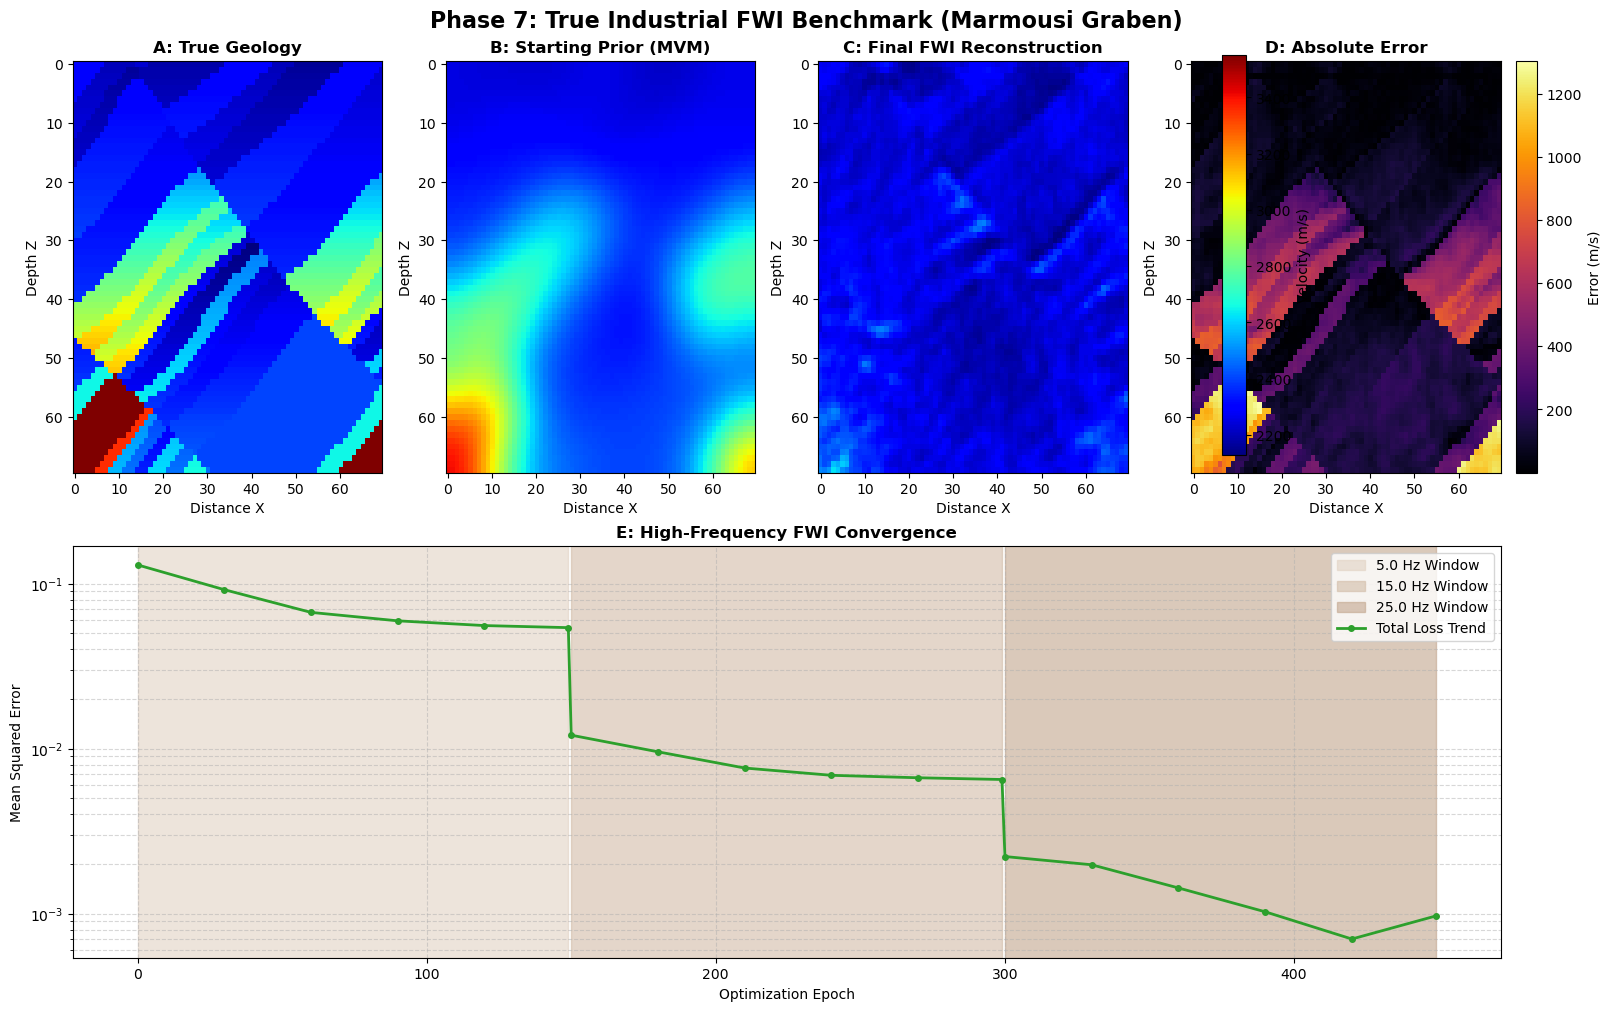


          FINAL INDUSTRIAL PERFORMANCE
Mean Spatial Absolute Error : 231.22 m/s
Maximum Spatial Deviation   : 1303.81 m/s


In [19]:
# ==========================================
# CELL 12: THE ULTIMATE VALIDATION DASHBOARD
# ==========================================
print("Generating Final Evaluation Suite...")

# 1. Extract Final Velocity Field
v_net_final.eval()
with torch.no_grad():
    v_pred_flat = v_net_final(x_flat, z_flat)
    v_pred_final_np = v_pred_flat.reshape(nx, nz).cpu().numpy()

# 2. Compute Absolute Error
absolute_error_final = np.abs(patch_vp - v_pred_final_np)

# 3. Construct the 4-Panel Suite
fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 4)

# Panel A: Ground Truth
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax1.set_title("A: True Geology", fontsize=12, fontweight='bold')

# Panel B: The Blurry Starting Prior (MVM)
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(mvm_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax2.set_title("B: Starting Prior (MVM)", fontsize=12, fontweight='bold')

# Panel C: Final DDR-PINN Reconstruction
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(v_pred_final_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax3.set_title("C: Final FWI Reconstruction", fontsize=12, fontweight='bold')

# Panel D: Absolute Error
ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(absolute_error_final.T, cmap='inferno', aspect='auto')
ax4.set_title("D: Absolute Error", fontsize=12, fontweight='bold')

# Add single colorbar for velocity panels (A, B, C)
cbar_ax = fig.add_axes([0.76, 0.55, 0.015, 0.4]) 
fig.colorbar(im3, cax=cbar_ax, label="Velocity (m/s)")
fig.colorbar(im4, ax=ax4, label="Error (m/s)")

# Set labels for top row
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("Distance X")
    ax.set_ylabel("Depth Z")

# Panel E: Convergence History
ax5 = fig.add_subplot(gs[1, :])
scales = np.array(history_final['scale'])
epochs = np.array(history_final['epoch'])
losses = np.array(history_final['loss'])

colors = ['#e1d2c3', '#d2bca7', '#c2a58d']
unique_scales = [5.0, 15.0, 25.0]

for idx, freq in enumerate(unique_scales):
    mask = scales == freq
    if np.any(mask):
        ep_sub = epochs[mask]
        ax5.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, 
                    label=f"{freq} Hz Window" if idx == 0 or history_final['scale'].count(freq) > 0 else "")

ax5.plot(epochs, losses, color='#2ca02c', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
ax5.set_yscale('log')
ax5.set_title("E: High-Frequency FWI Convergence", fontsize=12, fontweight='bold')
ax5.set_xlabel("Optimization Epoch")
ax5.set_ylabel("Mean Squared Error")
ax5.grid(True, which="both", linestyle="--", alpha=0.5)
ax5.legend(loc='upper right')

plt.suptitle("Phase 7: True Industrial FWI Benchmark (Marmousi Graben)", fontsize=16, fontweight='bold')
plt.show()

print("\n" + "="*50)
print("          FINAL INDUSTRIAL PERFORMANCE")
print("="*50)
print(f"Mean Spatial Absolute Error : {np.mean(absolute_error_final):.2f} m/s")
print(f"Maximum Spatial Deviation   : {np.max(absolute_error_final):.2f} m/s")
print("="*50)

In [20]:
# ==========================================
# CELL 13: THE DELTA-NETWORK ARCHITECTURE
# ==========================================
import torch
import torch.nn as nn

print("Initiating Phase 8: Delta-Network Construction...")

class FourierDeltaPINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Fourier Mapping for high-frequency coordinate projection
        self.B = nn.Parameter(torch.randn(2, 64) * 10.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(128, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 256), nn.Mish(),
            nn.Linear(256, 1)
        )
        
    def forward(self, x, z):
        coords = torch.cat([x, z], dim=1)
        proj = (2.0 * np.pi * coords) @ self.B
        fourier_features = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        
        out = self.net(fourier_features)
        
        # Tanh activation bounds the neural updates to +/- 1500 m/s
        # This prevents runaway numerical instabilities during FWI
        return 1500.0 * torch.tanh(out)

# Initialize the pristine perturbation network
v_net_delta = FourierDeltaPINN().to(device)

# Verify the Frozen MVM is still in GPU RAM from Phase 6
assert 'v_mvm_tensor' in locals(), "ERROR: v_mvm_tensor not found. Re-run Cell 9."

print("Delta-Network Initialized. Maximum perturbation bounded to +/- 1500 m/s.")

Initiating Phase 8: Delta-Network Construction...
Delta-Network Initialized. Maximum perturbation bounded to +/- 1500 m/s.


In [21]:
# ==========================================
# CELL 14: PHASE 8 - DELTA FWI (THE FINAL INVERSION)
# ==========================================
import deepwave
import torch.nn.functional as F

print("Igniting Phase 8: FWI Delta Sweep...")

# Multi-Scale Optimization Parameters
frequencies_delta = [5.0, 15.0, 25.0]
epochs_dict_delta = {5.0: 150, 15.0: 150, 25.0: 150}

# TV Annealing applies to the FINAL velocity field (MVM + Delta)
tv_weights_delta = {5.0: 1e-6, 15.0: 1e-7, 25.0: 0.0}

global_epoch_delta = 0
history_delta = {'epoch': [], 'loss': [], 'scale': []}

for freq in frequencies_delta:
    epochs_per_scale = epochs_dict_delta[freq]
    current_lambda_tv = tv_weights_delta[freq]
    print(f"==========================================")
    print(f"   INITIATING SCALE: {freq} Hz | Epochs: {epochs_per_scale} | TV: {current_lambda_tv}")
    print(f"==========================================")
    
    optimizer_delta = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3)
    safe_delay = 1.0 / freq
    
    source_amplitudes_scale = (
        deepwave.wavelets.ricker(freq, nt, dt, safe_delay)
        .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device)
    )
    
    # 1. Generate True Seismograms
    with torch.no_grad():
        out_true = deepwave.scalar(
            v_true, grid_spacing=dx, dt=dt,
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        observed_seismograms_scale = out_true[-1].clone().detach()
        
    # 2. Optimization Loop
    for epoch in range(epochs_per_scale):
        optimizer_delta.zero_grad()
        
        # Calculate Delta Update
        v_delta_flat = v_net_delta(x_flat, z_flat)
        v_delta = v_delta_flat.reshape(nx, nz) 
        
        # THE DELTA EQUATION: Final Velocity = Frozen MVM + Neural Perturbation
        v_final = v_mvm_tensor + v_delta
        
        # Run Physics Solver on the combined field
        out = deepwave.scalar(
            v_final, grid_spacing=dx, dt=dt, 
            source_amplitudes=source_amplitudes_scale,
            source_locations=source_locations,
            receiver_locations=receiver_locations
        )
        
        loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
        
        # Apply TV penalty to the combined structural field to keep geology coherent
        if current_lambda_tv > 0.0:
            tv_penalty = balanced_tv_loss(v_final, weight_x=1.0, weight_z=1.0)
            loss = loss_data + (current_lambda_tv * tv_penalty)
        else:
            loss = loss_data
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net_delta.parameters(), max_norm=1.0)
        optimizer_delta.step()
        
        if epoch % 30 == 0 or epoch == epochs_per_scale - 1:
            history_delta['epoch'].append(global_epoch_delta)
            history_delta['loss'].append(loss.item())
            history_delta['scale'].append(freq)
            print(f"Scale {freq}Hz | Epoch {global_epoch_delta:03d} | MSE: {loss.item():.6f}")
            
        global_epoch_delta += 1

print("\nPhase 8 Delta-FWI Complete.")

Igniting Phase 8: FWI Delta Sweep...
   INITIATING SCALE: 5.0 Hz | Epochs: 150 | TV: 1e-06
Scale 5.0Hz | Epoch 000 | MSE: 0.267936
Scale 5.0Hz | Epoch 030 | MSE: 0.122279
Scale 5.0Hz | Epoch 060 | MSE: 0.120444
Scale 5.0Hz | Epoch 090 | MSE: 0.116224
Scale 5.0Hz | Epoch 120 | MSE: 0.111211
Scale 5.0Hz | Epoch 149 | MSE: 0.106367
   INITIATING SCALE: 15.0 Hz | Epochs: 150 | TV: 1e-07
Scale 15.0Hz | Epoch 150 | MSE: 0.016853
Scale 15.0Hz | Epoch 180 | MSE: 0.014645
Scale 15.0Hz | Epoch 210 | MSE: 0.013039
Scale 15.0Hz | Epoch 240 | MSE: 0.012368
Scale 15.0Hz | Epoch 270 | MSE: 0.012052
Scale 15.0Hz | Epoch 299 | MSE: 0.011779
   INITIATING SCALE: 25.0 Hz | Epochs: 150 | TV: 0.0
Scale 25.0Hz | Epoch 300 | MSE: 0.001673
Scale 25.0Hz | Epoch 330 | MSE: 0.002015
Scale 25.0Hz | Epoch 360 | MSE: 0.001168
Scale 25.0Hz | Epoch 390 | MSE: 0.000758
Scale 25.0Hz | Epoch 420 | MSE: 0.000510
Scale 25.0Hz | Epoch 449 | MSE: 0.000625

Phase 8 Delta-FWI Complete.


Generating Final Delta Evaluation Suite...


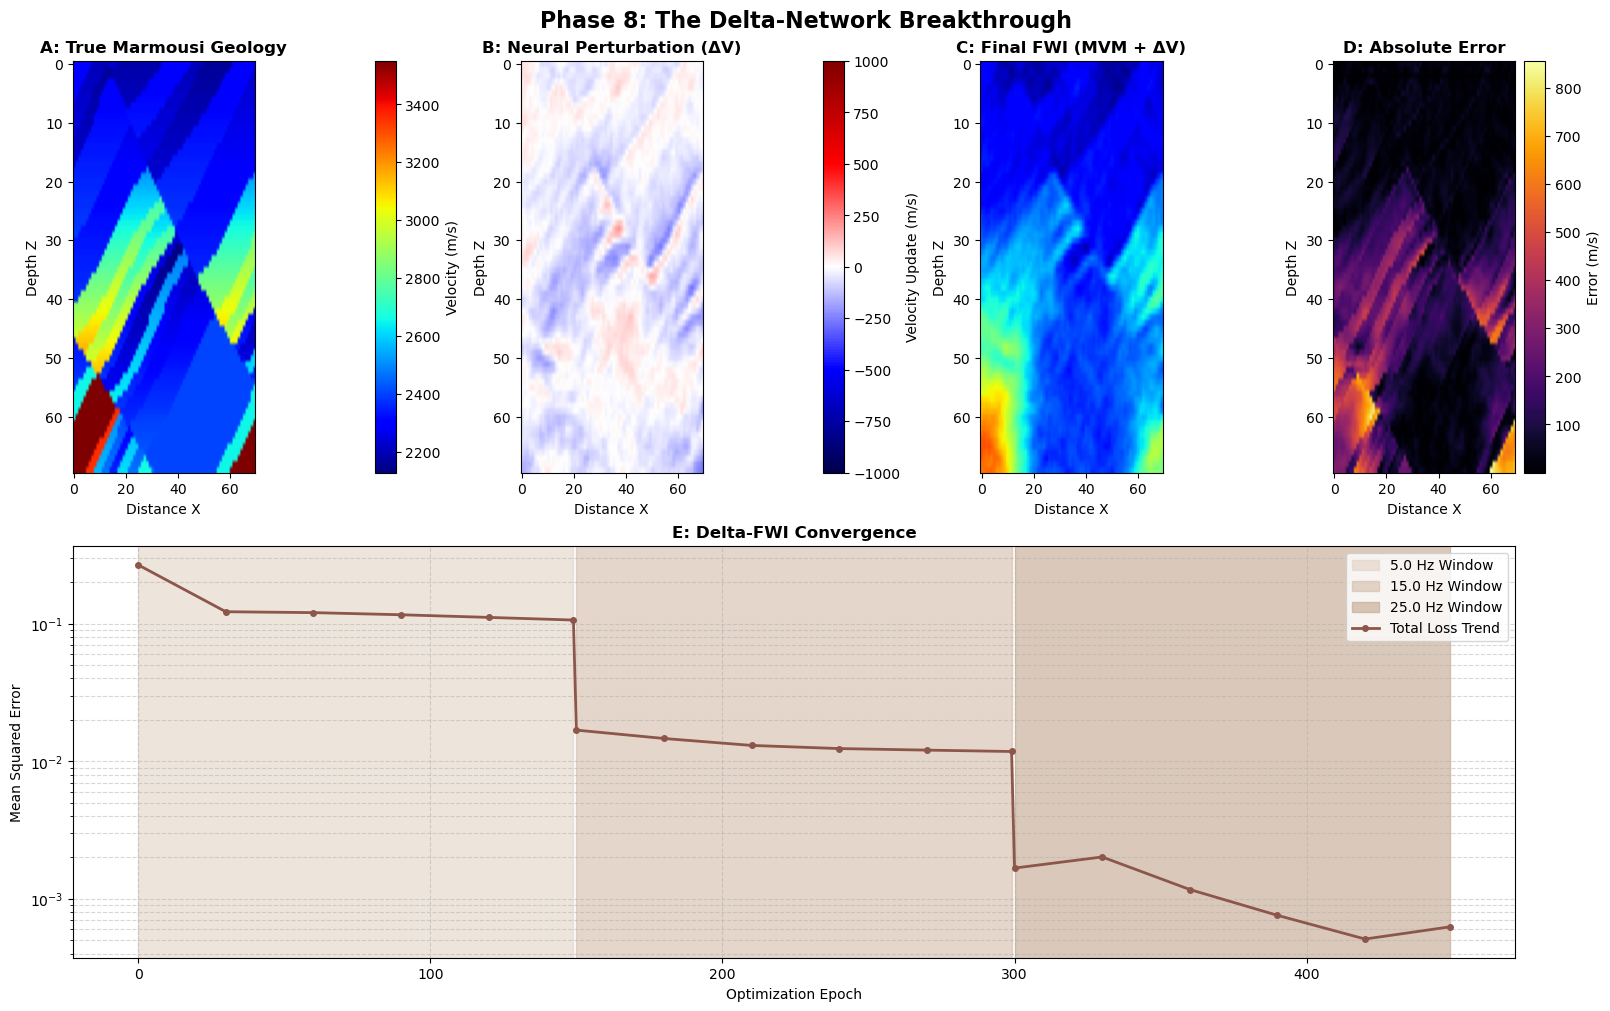


          FINAL DELTA-FWI PERFORMANCE
Mean Spatial Absolute Error : 125.83 m/s
Maximum Spatial Deviation   : 855.95 m/s


In [23]:
# ==========================================
# CELL 15: THE DELTA VALIDATION DASHBOARD
# ==========================================
import os
print("Generating Final Delta Evaluation Suite...")

# 1. Extract Final Fields
v_net_delta.eval()
with torch.no_grad():
    v_delta_flat = v_net_delta(x_flat, z_flat)
    v_delta_np = v_delta_flat.reshape(nx, nz).cpu().numpy()
    v_final_np = mvm_vp + v_delta_np

# 2. Compute Absolute Error
absolute_error_delta = np.abs(patch_vp - v_final_np)

# 3. Construct the 4-Panel Suite
fig = plt.figure(figsize=(16, 10), constrained_layout=True)
gs = fig.add_gridspec(2, 4)

# Panel A: Ground Truth
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax1.set_title("A: True Marmousi Geology", fontsize=12, fontweight='bold')

# Panel B: The Neural Perturbation (Delta)
ax2 = fig.add_subplot(gs[0, 1])
# Delta field needs a diverging colormap centered at 0
im2 = ax2.imshow(v_delta_np.T, cmap='seismic', aspect='auto', vmin=-1000, vmax=1000)
ax2.set_title("B: Neural Perturbation (ΔV)", fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=ax2, label="Velocity Update (m/s)")

# Panel C: Final Combined Reconstruction (MVM + Delta)
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(v_final_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
ax3.set_title("C: Final FWI (MVM + ΔV)", fontsize=12, fontweight='bold')
fig.colorbar(im3, ax=ax1, label="Velocity (m/s)") # Shared colorbar for A and C

# Panel D: Absolute Error
ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(absolute_error_delta.T, cmap='inferno', aspect='auto')
ax4.set_title("D: Absolute Error", fontsize=12, fontweight='bold')
fig.colorbar(im4, ax=ax4, label="Error (m/s)")

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlabel("Distance X")
    ax.set_ylabel("Depth Z")

# Panel E: Convergence History
ax5 = fig.add_subplot(gs[1, :])
scales = np.array(history_delta['scale'])
epochs = np.array(history_delta['epoch'])
losses = np.array(history_delta['loss'])

colors = ['#e1d2c3', '#d2bca7', '#c2a58d']
unique_scales = [5.0, 15.0, 25.0]

for idx, freq in enumerate(unique_scales):
    mask = scales == freq
    if np.any(mask):
        ep_sub = epochs[mask]
        ax5.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, 
                    label=f"{freq} Hz Window" if idx == 0 or history_delta['scale'].count(freq) > 0 else "")

ax5.plot(epochs, losses, color='#8c564b', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
ax5.set_yscale('log')
ax5.set_title("E: Delta-FWI Convergence", fontsize=12, fontweight='bold')
ax5.set_xlabel("Optimization Epoch")
ax5.set_ylabel("Mean Squared Error")
ax5.grid(True, which="both", linestyle="--", alpha=0.5)
ax5.legend(loc='upper right')

plt.suptitle("Phase 8: The Delta-Network Breakthrough", fontsize=16, fontweight='bold')

# --- EXPORT COMMAND ADDED HERE ---
os.makedirs("figures", exist_ok=True) # Ensure directory exists
plt.savefig("figures/ddr_pinn_final_dashboard.png", dpi=300, bbox_inches='tight')
# ---------------------------------

plt.show()

print("\n" + "="*50)
print("          FINAL DELTA-FWI PERFORMANCE")
print("="*50)
print(f"Mean Spatial Absolute Error : {np.mean(absolute_error_delta):.2f} m/s")
print(f"Maximum Spatial Deviation   : {np.max(absolute_error_delta):.2f} m/s")
print("="*50)

Generating Global Localization Map...


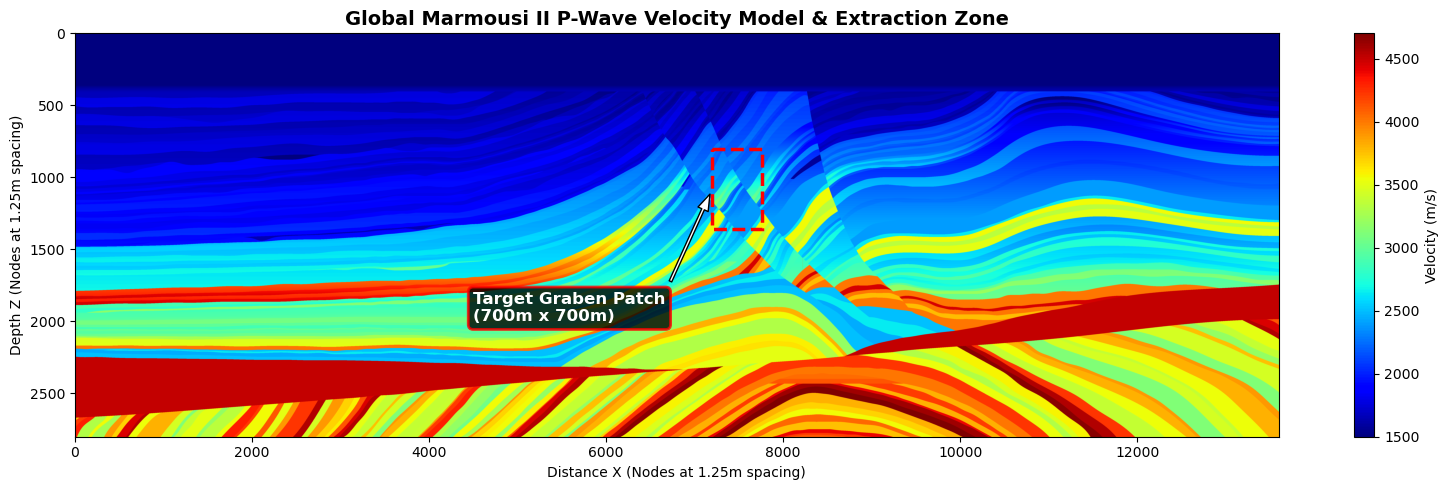

Localization map saved to figures/marmousi_global_localization.png


In [24]:
# ==========================================
# EXTRA CELL: GLOBAL MARMOUSI LOCALIZATION
# ==========================================
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Generating Global Localization Map...")

fig, ax = plt.subplots(figsize=(16, 5))

# Plot the massive global Marmousi model
im = ax.imshow(marmousi_vp_ms.T, cmap='jet', aspect='auto', vmin=1500, vmax=4700)
ax.set_title("Global Marmousi II P-Wave Velocity Model & Extraction Zone", fontsize=14, fontweight='bold')
ax.set_xlabel("Distance X (Nodes at 1.25m spacing)")
ax.set_ylabel("Depth Z (Nodes at 1.25m spacing)")
fig.colorbar(im, ax=ax, label="Velocity (m/s)")

# Draw the bounding box for our exact extraction patch
# x_start = 7200, z_start = 800, width/height = 560 nodes
rect = patches.Rectangle((7200, 800), 560, 560, linewidth=2.5, edgecolor='red', facecolor='none', linestyle='--')
ax.add_patch(rect)

# Add an annotation label pointing to the box
ax.annotate('Target Graben Patch\n(700m x 700m)', xy=(7200, 1080), xytext=(4500, 2000),
            arrowprops=dict(facecolor='white', shrink=0.05, width=2, headwidth=8),
            fontsize=12, color='white', fontweight='bold', 
            bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="red", lw=2, alpha=0.8))

plt.tight_layout()

# Export straight to the figures folder
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/marmousi_global_localization.png", dpi=300, bbox_inches='tight')
plt.show()

print("Localization map saved to figures/marmousi_global_localization.png")

In [25]:
# ==========================================
# PHASE 9: AUTOMATED SPATIAL CROSS-VALIDATION
# ==========================================
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import deepwave

print("Initializing Spatial Cross-Validation Automation...")

# The Three Extreme Physics Targets (560x560 node extraction)
validation_targets = {
    "Deep_Anticline": {"x_start": 6200, "z_start": 1800},
    "Shallow_Unconformity": {"x_start": 1500, "z_start": 600},
    "Complex_Overthrust": {"x_start": 8800, "z_start": 1200}
}

# Global Grid Parameters
step = 8
dx, dz = 10.0, 10.0
dt, nt = 0.001, 1000
num_shots, num_receivers = 21, 70

os.makedirs("figures", exist_ok=True)

# Main Automation Loop
for target_name, coords in validation_targets.items():
    print("\n" + "="*60)
    print(f"  TARGET ACQUIRED: {target_name.upper()} | Coords: {coords}")
    print("="*60)
    
    # 1. Extraction & Prior Generation
    x_s, z_s = coords["x_start"], coords["z_start"]
    patch_vp = marmousi_vp_ms[x_s:x_s+560:step, z_s:z_s+560:step]
    nx, nz = patch_vp.shape
    
    mvm_vp = ndimage.gaussian_filter(patch_vp, sigma=6.0)
    v_mvm_tensor = torch.tensor(mvm_vp, dtype=torch.float32, device=device)
    v_true = torch.tensor(patch_vp, dtype=torch.float32, device=device)
    
    # Coordinate Grid
    x_grid, z_grid = torch.meshgrid(torch.arange(nx, dtype=torch.float32), 
                                    torch.arange(nz, dtype=torch.float32), indexing='ij')
    x_flat = (x_grid.flatten().unsqueeze(1) / nx).to(device)
    z_flat = (z_grid.flatten().unsqueeze(1) / nz).to(device)
    
    # Acquisition Array
    source_locations = torch.zeros(num_shots, 1, 2, dtype=torch.long, device=device)
    source_locations[:, 0, 0] = torch.linspace(5, nx - 5, num_shots).long()
    source_locations[:, 0, 1] = 2 
    receiver_locations = torch.zeros(num_shots, num_receivers, 2, dtype=torch.long, device=device)
    receiver_locations[:, :, 0] = torch.arange(0, nx).repeat(num_shots, 1)
    receiver_locations[:, :, 1] = 2 

    # 2. Re-Initialize Delta Network for new geology
    v_net_delta = FourierDeltaPINN().to(device)
    optimizer_mvm = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3)
    
    print(f"[{target_name}] Stage 1: Transfer Learning (Zeroing Delta Network)...")
    target_zero_delta = torch.zeros_like(v_mvm_tensor)
    v_net_delta.train()
    for epoch in range(1500):
        optimizer_mvm.zero_grad()
        v_delta_flat = v_net_delta(x_flat, z_flat)
        v_delta = v_delta_flat.reshape(nx, nz)
        loss = F.mse_loss(v_delta, target_zero_delta)
        loss.backward()
        optimizer_mvm.step()

    # 3. Multi-Scale Delta FWI Sweep
    print(f"[{target_name}] Stage 2: Multi-Scale Physics Sweep...")
    frequencies_delta = [5.0, 15.0, 25.0]
    epochs_dict_delta = {5.0: 150, 15.0: 150, 25.0: 150}
    tv_weights_delta = {5.0: 1e-6, 15.0: 1e-7, 25.0: 0.0}
    history_delta = {'epoch': [], 'loss': [], 'scale': []}
    global_epoch_delta = 0

    for freq in frequencies_delta:
        epochs_per_scale = epochs_dict_delta[freq]
        current_lambda_tv = tv_weights_delta[freq]
        optimizer_delta = torch.optim.Adam(v_net_delta.parameters(), lr=1e-3)
        safe_delay = 1.0 / freq
        
        source_amplitudes_scale = (deepwave.wavelets.ricker(freq, nt, dt, safe_delay)
                                   .reshape(1, 1, -1).repeat(num_shots, 1, 1).to(device))
        
        with torch.no_grad():
            out_true = deepwave.scalar(v_true, grid_spacing=dx, dt=dt,
                                       source_amplitudes=source_amplitudes_scale,
                                       source_locations=source_locations,
                                       receiver_locations=receiver_locations)
            observed_seismograms_scale = out_true[-1].clone().detach()
            
        for epoch in range(epochs_per_scale):
            optimizer_delta.zero_grad()
            v_delta_flat = v_net_delta(x_flat, z_flat)
            v_delta = v_delta_flat.reshape(nx, nz) 
            v_final = v_mvm_tensor + v_delta
            
            out = deepwave.scalar(v_final, grid_spacing=dx, dt=dt, 
                                  source_amplitudes=source_amplitudes_scale,
                                  source_locations=source_locations,
                                  receiver_locations=receiver_locations)
            
            loss_data = F.mse_loss(out[-1], observed_seismograms_scale)
            
            if current_lambda_tv > 0.0:
                tv_penalty = balanced_tv_loss(v_final, weight_x=1.0, weight_z=1.0)
                loss = loss_data + (current_lambda_tv * tv_penalty)
            else:
                loss = loss_data
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(v_net_delta.parameters(), max_norm=1.0)
            optimizer_delta.step()
            
            if epoch == epochs_per_scale - 1:
                history_delta['epoch'].append(global_epoch_delta)
                history_delta['loss'].append(loss.item())
                history_delta['scale'].append(freq)
            global_epoch_delta += 1

    # 4. Generate & Save Specialized Dashboard
    print(f"[{target_name}] Exporting Dashboard...")
    v_net_delta.eval()
    with torch.no_grad():
        v_delta_flat = v_net_delta(x_flat, z_flat)
        v_delta_np = v_delta_flat.reshape(nx, nz).cpu().numpy()
        v_final_np = mvm_vp + v_delta_np

    absolute_error_delta = np.abs(patch_vp - v_final_np)

    fig = plt.figure(figsize=(16, 10), constrained_layout=True)
    gs = fig.add_gridspec(2, 4)

    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(patch_vp.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
    ax1.set_title(f"A: True Geology ({target_name})", fontsize=12, fontweight='bold')

    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(v_delta_np.T, cmap='seismic', aspect='auto', vmin=-1000, vmax=1000)
    ax2.set_title("B: Neural Perturbation (ΔV)", fontsize=12, fontweight='bold')
    fig.colorbar(im2, ax=ax2, label="Velocity Update (m/s)")

    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(v_final_np.T, cmap='jet', aspect='auto', vmin=patch_vp.min(), vmax=patch_vp.max())
    ax3.set_title("C: Final FWI (MVM + ΔV)", fontsize=12, fontweight='bold')
    fig.colorbar(im3, ax=ax1, label="Velocity (m/s)") 

    ax4 = fig.add_subplot(gs[0, 3])
    im4 = ax4.imshow(absolute_error_delta.T, cmap='inferno', aspect='auto')
    ax4.set_title("D: Absolute Error", fontsize=12, fontweight='bold')
    fig.colorbar(im4, ax=ax4, label="Error (m/s)")

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xlabel("Distance X")
        ax.set_ylabel("Depth Z")

    ax5 = fig.add_subplot(gs[1, :])
    scales = np.array(history_delta['scale'])
    epochs = np.array(history_delta['epoch'])
    losses = np.array(history_delta['loss'])
    colors = ['#e1d2c3', '#d2bca7', '#c2a58d']
    unique_scales = [5.0, 15.0, 25.0]

    for idx, freq in enumerate(unique_scales):
        mask = scales == freq
        if np.any(mask):
            ep_sub = epochs[mask]
            ax5.axvspan(ep_sub.min(), ep_sub.max(), color=colors[idx], alpha=0.6, 
                        label=f"{freq} Hz Window" if idx == 0 else "")

    ax5.plot(epochs, losses, color='#8c564b', linewidth=2, marker='o', markersize=4, label='Total Loss Trend')
    ax5.set_yscale('log')
    ax5.set_title(f"E: Delta-FWI Convergence ({target_name})", fontsize=12, fontweight='bold')
    ax5.set_xlabel("Optimization Epoch")
    ax5.set_ylabel("Mean Squared Error")
    ax5.grid(True, which="both", linestyle="--", alpha=0.5)
    ax5.legend(loc='upper right')

    plt.suptitle(f"Target Resolution: {target_name.replace('_', ' ')}", fontsize=16, fontweight='bold')
    
    # Save the figure dynamically and flush Matplotlib memory
    plt.savefig(f"figures/marmousi_{target_name.lower()}_dashboard.png", dpi=300, bbox_inches='tight')
    plt.close(fig) # Crucial: Prevents RAM overload during multi-patch loops
    
    print(f"[{target_name}] Validation Complete. Mean Error: {np.mean(absolute_error_delta):.2f} m/s")
    
print("\n" + "="*60)
print("ALL SPATIAL CROSS-VALIDATIONS EXECUTED SUCCESSFULLY.")
print("Check the 'figures/' directory for the output dashboards.")
print("="*60)

Initializing Spatial Cross-Validation Automation...

  TARGET ACQUIRED: DEEP_ANTICLINE | Coords: {'x_start': 6200, 'z_start': 1800}
[Deep_Anticline] Stage 1: Transfer Learning (Zeroing Delta Network)...
[Deep_Anticline] Stage 2: Multi-Scale Physics Sweep...
[Deep_Anticline] Exporting Dashboard...
[Deep_Anticline] Validation Complete. Mean Error: 212.49 m/s

  TARGET ACQUIRED: SHALLOW_UNCONFORMITY | Coords: {'x_start': 1500, 'z_start': 600}
[Shallow_Unconformity] Stage 1: Transfer Learning (Zeroing Delta Network)...
[Shallow_Unconformity] Stage 2: Multi-Scale Physics Sweep...


C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:905: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1027.9998779296875, and a grid cell spacing of 10.0, there are only 4.11.
  warnings.warn(
C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:905: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1498.928466796875, and a grid cell spacing of 10.0, there are only 6.00.
  warnings.warn(
C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:905: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 25.0, a minimum non-zero velocity of 1496.6263427734375, and a grid cell spacing of 10.0, there are only 5.99.
  warnings.warn(
C:\Users\limac\miniconda3\envs\project-env\lib\site-packages\deepwave\common.py:905: UserWar

[Shallow_Unconformity] Exporting Dashboard...
[Shallow_Unconformity] Validation Complete. Mean Error: 40.74 m/s

  TARGET ACQUIRED: COMPLEX_OVERTHRUST | Coords: {'x_start': 8800, 'z_start': 1200}
[Complex_Overthrust] Stage 1: Transfer Learning (Zeroing Delta Network)...
[Complex_Overthrust] Stage 2: Multi-Scale Physics Sweep...
[Complex_Overthrust] Exporting Dashboard...
[Complex_Overthrust] Validation Complete. Mean Error: 204.53 m/s

ALL SPATIAL CROSS-VALIDATIONS EXECUTED SUCCESSFULLY.
Check the 'figures/' directory for the output dashboards.


Generating Multi-Target Global Localization Map...


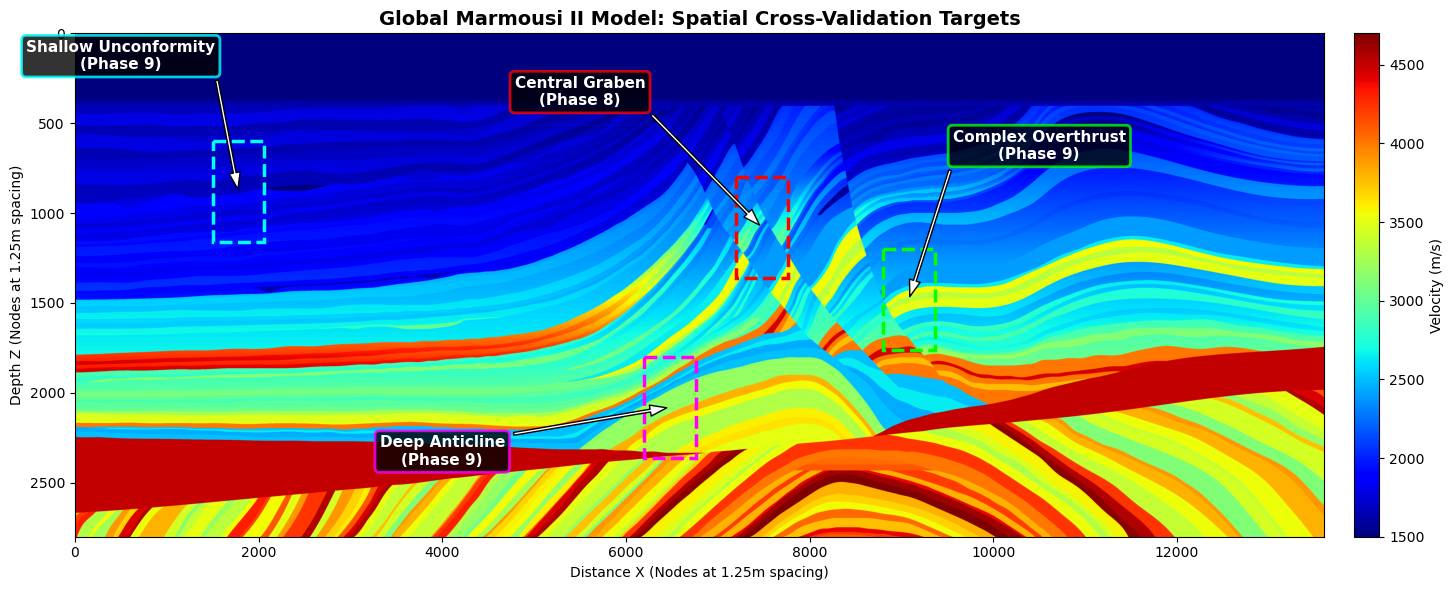

Updated Multi-Target Localization map saved to figures/marmousi_global_localization.png


In [26]:
# ==========================================
# EXTRA CELL: UPDATED GLOBAL MARMOUSI LOCALIZATION
# ==========================================
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Generating Multi-Target Global Localization Map...")

fig, ax = plt.subplots(figsize=(16, 6))

# Plot the massive global Marmousi model
im = ax.imshow(marmousi_vp_ms.T, cmap='jet', aspect='auto', vmin=1500, vmax=4700)
ax.set_title("Global Marmousi II Model: Spatial Cross-Validation Targets", fontsize=14, fontweight='bold')
ax.set_xlabel("Distance X (Nodes at 1.25m spacing)")
ax.set_ylabel("Depth Z (Nodes at 1.25m spacing)")
fig.colorbar(im, ax=ax, label="Velocity (m/s)", pad=0.02)

# Dictionary of all 4 targets (560x560 patches)
# Format: "Name": [(x, z), (text_x, text_y), "color"]
targets = {
    "Central Graben\n(Phase 8)": [(7200, 800), (5500, 400), "red"],
    "Shallow Unconformity\n(Phase 9)": [(1500, 600), (500, 200), "cyan"],
    "Complex Overthrust\n(Phase 9)": [(8800, 1200), (10500, 700), "lime"],
    "Deep Anticline\n(Phase 9)": [(6200, 1800), (4000, 2400), "magenta"]
}

# Loop through and draw each box and label
for name, data in targets.items():
    coords = data[0]
    text_xy = data[1]
    box_color = data[2]
    
    # Draw the bounding box
    rect = patches.Rectangle(coords, 560, 560, linewidth=2.5, edgecolor=box_color, facecolor='none', linestyle='--')
    ax.add_patch(rect)

    # Add the annotation arrow and label
    ax.annotate(name, xy=(coords[0] + 280, coords[1] + 280), xytext=text_xy,
                arrowprops=dict(facecolor='white', shrink=0.02, width=2, headwidth=8),
                fontsize=11, color='white', fontweight='bold', ha='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="black", ec=box_color, lw=2, alpha=0.8))

plt.tight_layout()

# Export and overwrite the previous map
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/marmousi_global_localization.png", dpi=300, bbox_inches='tight')
plt.show()

print("Updated Multi-Target Localization map saved to figures/marmousi_global_localization.png")